# Bronze Layer EDA

Exploratory analysis of the nine raw landing tables. Goal is to inventory every data quality issue so the Silver transforms in `src/silver/transforms.py` cover each one. Runs top to bottom on local parquet, no database needed.

## Setup

Load all nine Bronze tables into memory.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
BRONZE = ROOT / "data" / "bronze"
TABLES = [
    "dim_customers",
    "dim_date",
    "dim_stores",
    "dim_employees",
    "dim_products",
    "fact_orders_2022_2023",
    "fact_orders_2024",
    "fact_order_details",
    "fact_returns",
]
bronze = {name: pd.read_parquet(BRONZE / f"{name}.parquet") for name in TABLES}
print("loaded", len(bronze), "tables from", BRONZE)

loaded 9 tables from C:\Git-Repo\ola\data\bronze


## Table shapes

Row and column counts per table.

In [2]:
shape_df = pd.DataFrame(
    [
        {"table": name, "rows": df.shape[0], "cols": df.shape[1]}
        for name, df in bronze.items()
    ]
)
shape_df

,table,rows,cols
0,dim_customers,3050,12
1,dim_date,1096,15
2,dim_stores,15,10
3,dim_employees,216,10
4,dim_products,345,12
5,fact_orders_2022_2023,7942,12
6,fact_orders_2024,4058,12
7,fact_order_details,25099,12
8,fact_returns,1056,9


## Schemas

Column dtypes for the three tables that need the most cleaning.

In [3]:
from src.bronze.ingest import schema_of

for name in ["dim_customers", "dim_products", "fact_orders_2022_2023"]:
    print("==", name)
    for col, dtype in schema_of(bronze[name]).items():
        print(f"  {col}: {dtype}")

== dim_customers
  customer_id: str
  full_name: str
  gender: str
  birth_date: str
  phone: int64
  email: str
  city: str
  region: str
  loyalty_tier: str
  registration_date: str
  loaded_at: datetime64[us]
  _batch_id: str
== dim_products
  product_id: str
  product_name_raw: str
  category: str
  subcategory: str
  brand: str
  unit_price_text: str
  unit_price: int64
  unit_cost: int64
  stock_qty: int64
  is_active: int64
  loaded_at: datetime64[us]
  _batch_id: str
== fact_orders_2022_2023
  order_id: str
  order_date: str
  date_id: int64
  customer_id: str
  store_id: int64
  employee_id: str
  payment_method: str
  order_status: str
  total_revenue: float64
  total_cost: float64
  loaded_at: datetime64[us]
  _batch_id: str


## Missing values

Null counts per column across all tables.

In [4]:
missing = pd.DataFrame(
    [
        {"table": name, "column": col, "nulls": int(df[col].isna().sum())}
        for name, df in bronze.items()
        for col in df.columns
    ]
)
missing = (
    missing[missing["nulls"] > 0]
    .sort_values("nulls", ascending=False)
    .reset_index(drop=True)
)
missing

,table,column,nulls
0,fact_orders_2022_2023,employee_id,427
1,dim_customers,email,382
2,fact_orders_2024,employee_id,205


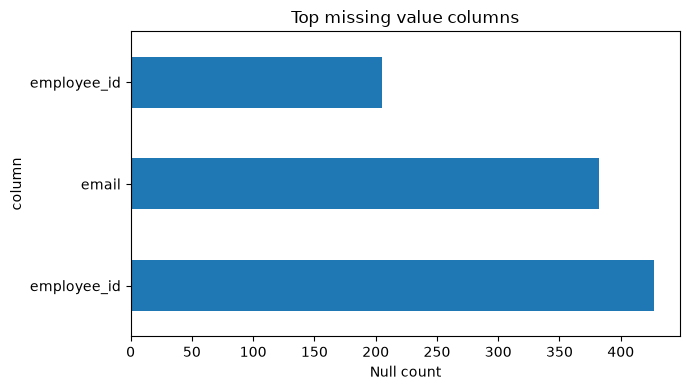

In [5]:
ax = missing.head(10).plot.barh(x="column", y="nulls", legend=False, figsize=(7, 4))
ax.set_title("Top missing value columns")
ax.set_xlabel("Null count")
plt.tight_layout()
plt.show()

## Duplicates

Duplicate counts on each natural business key.

In [6]:
keys = {
    "dim_customers": "customer_id",
    "dim_products": "product_id",
    "fact_orders_2022_2023": "order_id",
    "fact_orders_2024": "order_id",
    "fact_returns": "return_id",
    "fact_order_details": "detail_id",
}
pd.DataFrame(
    [
        {
            "table": t,
            "key": k,
            "duplicates": int(bronze[t].duplicated(subset=[k]).sum()),
        }
        for t, k in keys.items()
    ]
)

,table,key,duplicates
0,dim_customers,customer_id,50
1,dim_products,product_id,0
2,fact_orders_2022_2023,order_id,0
3,fact_orders_2024,order_id,0
4,fact_returns,return_id,0
5,fact_order_details,detail_id,0


## Text issues

Inconsistent casing and untrimmed values that Silver must normalize.

In [7]:
cust = bronze["dim_customers"]
print("gender values:", sorted(cust["gender"].dropna().astype(str).unique()))
print("region values:", sorted(cust["region"].dropna().astype(str).unique()))
orders_raw = bronze["fact_orders_2022_2023"]
pay = orders_raw["payment_method"].astype(str)
print("payment values:", sorted(pay.unique()))
print("untrimmed payment rows:", int((pay != pay.str.strip()).sum()))

gender values: ['FEMALE', 'Female', 'MALE', 'Male', 'female', 'male']
region values: ['Alexandria', 'Canal Zone', 'Greater Cairo', 'Nile Delta', 'Red Sea', 'South Sinai', 'Upper Egypt']
payment values: ['  Cash  ', '  Credit Card  ', '  Debit Card  ', '  Fawry  ', '  InstaPay  ', '  Vodafone Cash  ', 'Cash', 'Credit Card', 'Debit Card', 'Fawry', 'InstaPay', 'Vodafone Cash']
untrimmed payment rows: 1461


## Product name structure

Raw names carry pipe separated attributes plus a redundant price text column.

In [8]:
prod = bronze["dim_products"]
prod[["product_name_raw", "unit_price_text", "unit_price"]].head(5)
print(
    "rows with pipes:",
    int(prod["product_name_raw"].str.contains("|", regex=False).sum()),
    "/",
    len(prod),
)

rows with pipes: 308 / 345


## Order volume and revenue

Monthly trend across both order frames plus status mix.

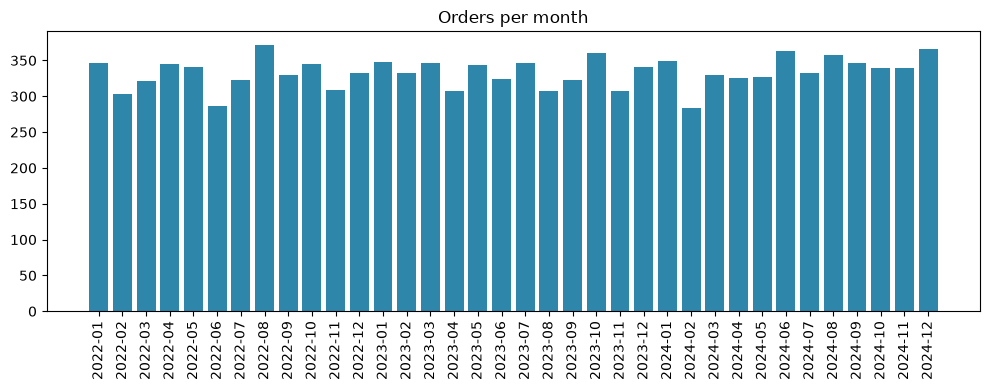

order_status
Completed    10442
Returned      1063
Cancelled      495


In [9]:
orders_all = pd.concat(
    [bronze["fact_orders_2022_2023"], bronze["fact_orders_2024"]], ignore_index=True
)
orders_all["month"] = (
    pd.to_datetime(orders_all["order_date"]).dt.to_period("M").astype(str)
)
monthly = (
    orders_all.groupby("month")
    .agg(orders=("order_id", "nunique"), revenue=("total_revenue", "sum"))
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(monthly["month"], monthly["orders"], color="#2E86AB")
ax1.set_title("Orders per month")
ax1.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()
print(orders_all["order_status"].value_counts().to_string())

## Returns

Return reasons and whether every return links to a known order.

In [10]:
rets = bronze["fact_returns"]
details = bronze["fact_order_details"]
print(rets["return_reason"].value_counts().to_string())
print(
    "orphan returns:",
    int((~rets["order_id"].isin(set(details["order_id"]))).sum()),
    "/",
    len(rets),
)

return_reason
Duplicate Order         197
Defective Product       181
Wrong Item Delivered    175
Size Issue              173
Changed Mind            172
Quality Issue           158
orphan returns: 0 / 1056


## Findings for Silver

Duplicates on customers, missing emails, mixed gender casing, untrimmed payment text, pipe separated product names, two order frames to append, and returns to enrich from details. Each maps to one function in `src/silver/transforms.py`, verified in the next notebook.